# התאמת מודלים והתפלגויות בעזרת SciPy

במחברת זו נראה איך SciPy עוזרת לנו לעבור מנקודות מדידה למודל כמותי. נתחיל בעקומת כיול פשוטה, נבדוק את השגיאות בעזרת היסטוגרמה, ואז נבצע התאמה לא־לינארית של דעיכה קינטית.

המטרה אינה ללמוד סטטיסטיקה מתקדמת, אלא לראות תבנית עבודה שימושית: מגדירים מודל, משווים אותו לנתונים, ומסתכלים על מה שנשאר.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm

## דוגמה 1: עקומת כיול
נניח שמדדנו בליעה של תמיסות בריכוזים ידועים. לפי חוק בר־למברט, בתחום מתאים, הבליעה אמורה להיות בקירוב לינארית בריכוז:
$$A = a c + b$$
כאן $c$ הוא הריכוז, $A$ היא הבליעה, $a$הוא השיפוע, ו־ $b$ הוא חיתוך עם הציר. בפועל נקבל גם רעש מדידה.

In [2]:
rng = np.random.default_rng(42)

concentration = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]) # mmol/L
true_slope = 0.75
true_intercept = 0.04
noise = rng.normal(loc=0.0, scale=0.035, size=concentration.size)

absorbance = true_slope * concentration + true_intercept + noise

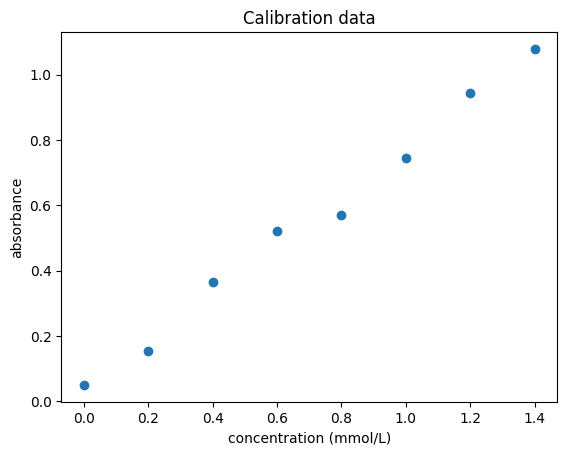

In [3]:
plt.figure()
plt.scatter(concentration, absorbance)
plt.xlabel('concentration (mmol/L)')
plt.ylabel('absorbance')
plt.title('Calibration data')
plt.show()

כדי לבצע התאמה בעזרת `curve_fit`, קודם מגדירים פונקציה של המודל. הארגומנט הראשון הוא המשתנה הבלתי־תלוי, ואחריו הפרמטרים שאותם רוצים למצוא.

In [4]:
def linear_model(c, slope, intercept):
    return slope * c + intercept

params, covariance = curve_fit(linear_model, concentration, absorbance)
slope, intercept = params

print(f'slope = {slope:.3f}')
print(f'intercept = {intercept:.3f}')

slope = 0.734
intercept = 0.040


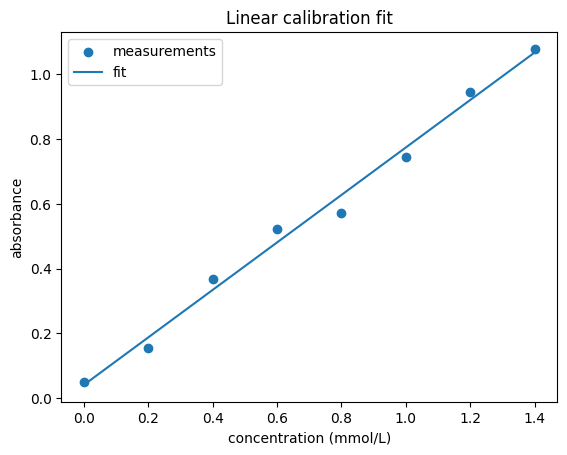

In [5]:
c_fit = np.linspace(0, 1.4, 200)
A_fit = linear_model(c_fit, slope, intercept)

plt.figure()
plt.scatter(concentration, absorbance, label='measurements')
plt.plot(c_fit, A_fit, label='fit')
plt.xlabel('concentration (mmol/L)')
plt.ylabel('absorbance')
plt.title('Linear calibration fit')
plt.legend()
plt.show()

כעת אפשר להשתמש בעקומת הכיול כדי להעריך ריכוז של דוגמה לא־ידועה. אם הבליעה של הדוגמה היא $A_\mathrm{unknown}$, אז לפי המודל הלינארי:\n\n$$c_\mathrm{unknown} = \frac{A_\mathrm{unknown} - b}{a}$$

In [6]:
A_unknown = 0.62
c_unknown = (A_unknown - intercept) / slope

print(f'unknown concentration = {c_unknown:.3f} mmol/L')

unknown concentration = 0.790 mmol/L


## שאריות והיסטוגרמה\n\nהשארית היא ההפרש בין המדידה לבין ערך המודל באותה נקודה. אם המודל סביר והרעש אקראי, השאריות לא אמורות להראות מבנה ברור.

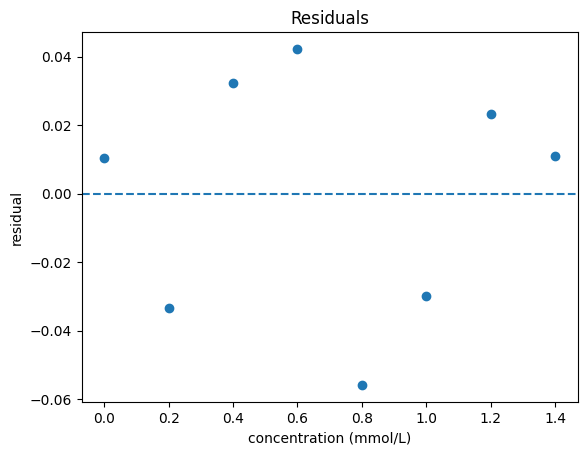

In [7]:
predicted = linear_model(concentration, slope, intercept)
residuals = absorbance - predicted

plt.figure()
plt.axhline(0, linestyle='--')
plt.scatter(concentration, residuals)
plt.xlabel('concentration (mmol/L)')
plt.ylabel('residual')
plt.title('Residuals')
plt.show()

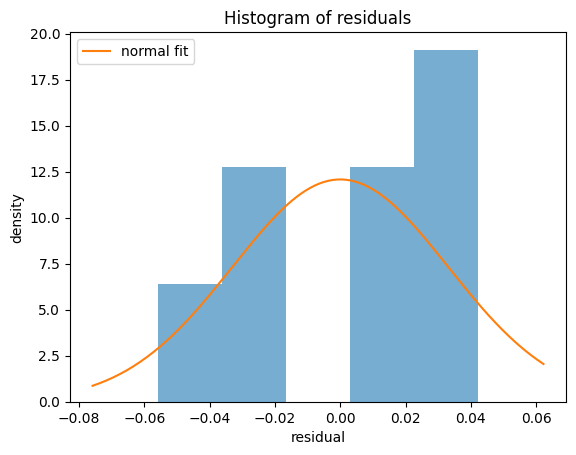

mean residual = 0.0000
std residual = 0.0330


In [8]:
mu, sigma = norm.fit(residuals)
x = np.linspace(residuals.min() - 0.02, residuals.max() + 0.02, 200)

plt.figure()
plt.hist(residuals, bins=5, density=True, alpha=0.6)
plt.plot(x, norm.pdf(x, mu, sigma), label='normal fit')
plt.xlabel('residual')
plt.ylabel('density')
plt.title('Histogram of residuals')
plt.legend()
plt.show()

print(f'mean residual = {mu:.4f}')
print(f'std residual = {sigma:.4f}')

ההיסטוגרמה כאן מבוססת על מעט נקודות, ולכן לא צריך להסיק ממנה יותר מדי. הרעיון החשוב הוא שאפשר לשאול האם השגיאות נראות אקראיות או שיש בהן תבנית.

## דוגמה 2: התאמה לא־לינארית לדעיכה קינטית\n\nכעת נשתמש באותה פקודה, אבל עם מודל לא־לינארי. נניח שמדדנו בליעה של חומר שמגיב לפי קינטיקה מסדר ראשון. אם הבליעה פרופורציונית לריכוז, נקבל:\n\n$$A(t) = A_\infty + (A_0 - A_\infty)e^{-kt}$$\n\nכאן $k$ הוא קבוע הקצב, ו־$A_\infty$ הוא ערך הבליעה לאחר זמן ארוך.

In [9]:
time = np.linspace(0, 10, 18) # min
true_A0 = 1.20
true_Ainf = 0.18
true_k = 0.32

def decay_model(t, A0, Ainf, k):
    return Ainf + (A0 - Ainf) * np.exp(-k * t)

abs_decay = decay_model(time, true_A0, true_Ainf, true_k)
abs_decay += rng.normal(0.0, 0.025, size=time.size)

In [10]:
guess = [1.0, 0.1, 0.2]
params, covariance = curve_fit(decay_model, time, abs_decay, p0=guess)
A0_fit, Ainf_fit, k_fit = params

print(f'A0 = {A0_fit:.3f}')
print(f'Ainf = {Ainf_fit:.3f}')
print(f'k = {k_fit:.3f} 1/min')

A0 = 1.196
Ainf = 0.166
k = 0.305 1/min


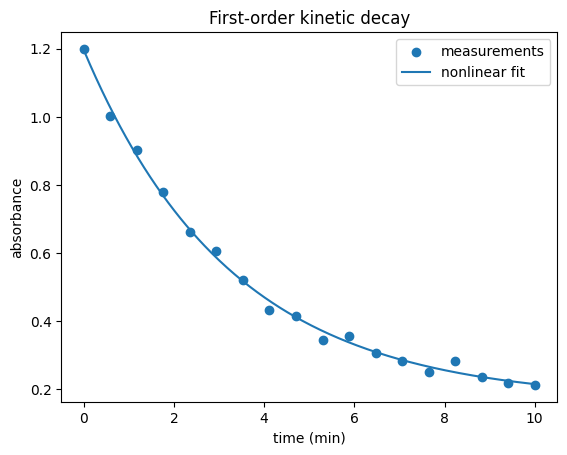

In [11]:
t_fit = np.linspace(0, 10, 300)
A_fit = decay_model(t_fit, A0_fit, Ainf_fit, k_fit)

plt.figure()
plt.scatter(time, abs_decay, label='measurements')
plt.plot(t_fit, A_fit, label='nonlinear fit')
plt.xlabel('time (min)')
plt.ylabel('absorbance')
plt.title('First-order kinetic decay')
plt.legend()
plt.show()

שימו לב שהתהליך המחשבתי דומה מאוד להתאמה הלינארית: מגדירים מודל, נותנים ל־SciPy את הנתונים, ומקבלים פרמטרים. ההבדל הוא שהקשר בין הפרמטרים לבין הנתונים כבר אינו קו ישר.

## תרגילים קצרים\n\n1. הגדילו את רעש המדידה בעקומת הכיול ובדקו מה קורה לשיפוע המותאם.\n2. שנו את $k$ בדעיכה הקינטית וראו איך משתנה הגרף.\n3. נסו לבצע התאמה לדעיכה בלי לתת ניחוש התחלתי `p0`. האם התוצאה משתנה?